# Partie 1 : Construction du maillage

On considère la fonction $f$ représentant la densité électronique d'un crystal 2D de structure rectangulaire de dimensions $L_x \times L_y = 20 \times 20$ nm$^2$ :

$$
\begin{array}{rccl}
f : & [0; L_x] \times [0; L_y]  &\mapsto &  \mathbb{R}\\
    & (x, y) & \rightarrow &  A_1 \cos \left(\frac{2\pi}{\lambda_1}x \right) + A_2 \cos \left(\frac{2\pi}{\lambda_2} y \right)
\end{array}
$$

avec $\lambda_1 = 2$ nm  et $\lambda_2 = 4$ nm.
Par commodité, on prendra des amplitudes $A_{1, 2}$ unitaires.

On souhaite représenter numériquement cette fonction sur un maillage bi-dimensionnel de $n_x$ points  sur $n_y$.
Les valeurs numériques de $A_{1, 2}$ et $\lambda_{1, 2}$ sont déclarées ci-dessous.

1. Laquelle des trois déclarations suivantes est-elle à privilégier ? Justifier la réponse.

In [3]:
# Proposition A
Lx, Ly = 20e-9, 20e-9
A1, lambda1 = 1, 2e-9
A2, lambda2 = 1, 4e-9

# Proposition B
Lx, Ly = 0.00000002, 0.00000002
A1, lambda1 = 1, 0.000000002
A2, lambda2 = 1, 0.000000004

# Proposition C
Lx, Ly = 20, 20
A1, lambda1 = 1, 2
A2, lambda2 = 1, 4

Question 1:

Il faut privilégier la proposition C car la proposition B nous donne des termes trop long difficilement lisibles, et la proposition C réalisera des approximations.

2. Construire deux listes _X_ et _Y_ contenant chacune 14 points répartis uniformément (échantillonnage uniforme) sur les intervalles $[0; L_x]$ et $[0; L_y]$ respectivement.
Compléter la fonction _echantillonnageXY_ de telle sorte que la cellule ci-dessous produise les deux listes attendues.

In [4]:
import numpy as np

def echantillonnageXY (Lx, Ly, nx, ny): 
       X = []
       Y = []
       for i in range(nx):
              X.append(Lx / (nx-1) * i)
       for i in range(ny):
              Y.append(Ly / (ny-1) * i)
       return np.array(X), np.array(Y)
nx, ny = 14, 14
X, Y = echantillonnageXY (Lx, Ly, nx, ny)
print(X, Y)

[ 0.          1.53846154  3.07692308  4.61538462  6.15384615  7.69230769
  9.23076923 10.76923077 12.30769231 13.84615385 15.38461538 16.92307692
 18.46153846 20.        ] [ 0.          1.53846154  3.07692308  4.61538462  6.15384615  7.69230769
  9.23076923 10.76923077 12.30769231 13.84615385 15.38461538 16.92307692
 18.46153846 20.        ]


Fait.

3. Ecrire la fonction $f (x, y)$ en utilisant la fonction $d (x)$

In [5]:


def d (x, L, A):
    return A * np.cos (2 * np.pi / L * x)

def f (x, L1, A1, y, L2, A2):
    Z = d(x, L1, A1) + d (y, L2, A2)
    return Z


4. Calculer la fonction $f(x,y)$ sur le maillage et les stocker dans un tuple _Z_ avec la structure Z [i][j] = $f (x_j, y_i)$

In [ ]:
def d (x, L, A):
    return A * np.cos (2 * np.pi / L * x)

def fxy (x, L1, A1, y, L2, A2):
    Z = []
    for i in y:
        K = []
        for k in x:
            K.append(f(k, L1, A1, i, L2, A2))
        Z.append(K)
    return np.array(Z)

fxy(X, lambda1, A1, Y, lambda2, A2) 

array([[ 2.        ,  1.12053668,  0.02905818,  0.64539511,  1.88545603,
         1.56806475,  0.25148925,  0.25148925,  1.56806475,  1.88545603,
         0.64539511,  0.02905818,  1.12053668,  2.        ],
       [ 0.25148925, -0.62797407, -1.71945257, -1.10311564,  0.13694528,
        -0.180446  , -1.4970215 , -1.4970215 , -0.180446  ,  0.13694528,
        -1.10311564, -1.71945257, -0.62797407,  0.25148925],
       [ 1.12053668,  0.24107336, -0.85040514, -0.23406821,  1.00599271,
         0.68860143, -0.62797407, -0.62797407,  0.68860143,  1.00599271,
        -0.23406821, -0.85040514,  0.24107336,  1.12053668],
       [ 1.56806475,  0.68860143, -0.40287707,  0.21345986,  1.45352077,
         1.13612949, -0.180446  , -0.180446  ,  1.13612949,  1.45352077,
         0.21345986, -0.40287707,  0.68860143,  1.56806475],
       [ 0.02905818, -0.85040514, -1.94188363, -1.3255467 , -0.08548579,
        -0.40287707, -1.71945257, -1.71945257, -0.40287707, -0.08548579,
        -1.3255467 , -1.94

**Remarque :**  le maillage de l'espace 2D est stocké sous la forme d'une liste de $n_y$ lignes de $n_x$ points.

### Partie 2 - Représentation 2D avec la fonction matplotlib  _imshow_

Par défaut, la fonction _imshow_ dispose l'origine des ordonnées en haut du graphe; le paramètre _origin_ doit prendre la valeur 'lower' pour rétablir l'origine en bas à gauche.

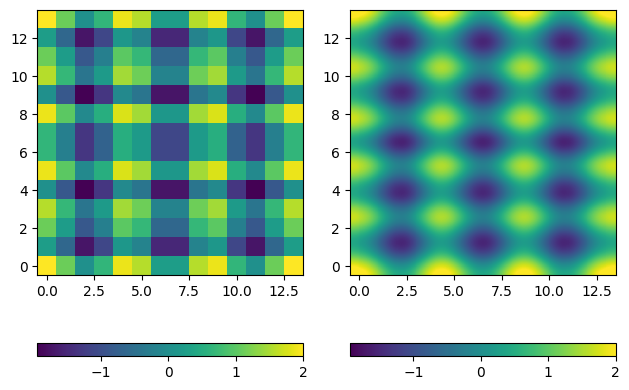

In [7]:
import matplotlib.pyplot as plt
import numpy as np
Z = fxy(X, lambda1, A1, Y, lambda2, A2)
# plot with imshow
fig, ax = plt.subplots (ncols = 2)
im1 = ax[0].imshow (Z, origin = 'lower')
fig.colorbar(im1, ax=ax [0], orientation = 'horizontal')

im2 = ax[1].imshow (Z, origin = 'lower', interpolation = 'bessel')
fig.colorbar(im2, ax=ax [1], orientation = 'horizontal')

plt.tight_layout ()

![](data/partie2.png)

La tentative de lissage des données par une interpolation de type Bessel rend une représentation plausible mais incorrecte.

5. Après avoir calculé le nombre d'échantillons (de points de maillage) contenus dans un segment de 4 nm, illustrer la situation en représentant les échantillons sur le graphe de $f (x, 0)$ pour $0 \le x \le 4$ nm.
Expliquer pourquoi le lissage produit une représentation qui n'est pas cohérente avec l'expression de $f$.

(0.0, 20.0)

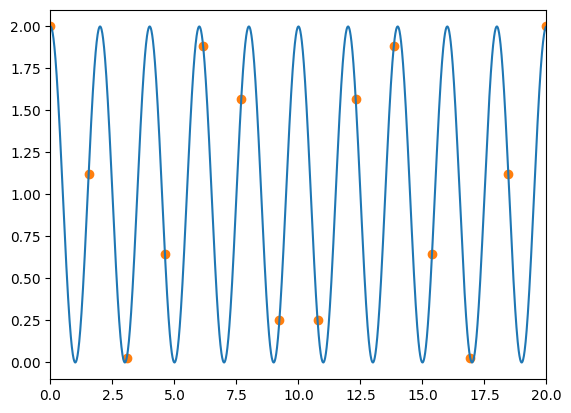

In [8]:
fig, ax = plt.subplots()
y = 0

ax.plot(X, f(X, lambda1, A1, y, lambda2, A2), ls = "", marker = "o", color = 'C1')

XX = np.linspace(0, 20, 2000)
ax.plot(XX, f(XX, lambda1, A1, y, lambda2, A2), color = 'C0')
ax.set_xlim((0, 20))



Pour la suite, on choisira un maillage contenant 40 points par période dans chaque direction de l'espace.

6. Calculer les nouvelles valeurs de $n_x$ et $n_y$

In [42]:
N = 40
nx = int(N * (Lx/lambda1))
ny = int(N * (Ly/lambda2))

X, Y = echantillonnageXY (Lx, Ly, nx, ny)

La figure ci-dessous représente le résultat du nouvel échantillonnage avec et sans interpolation.
Finalement, l'accord entre les deux représentations indique que l'échantillonnage est satisfaisant.

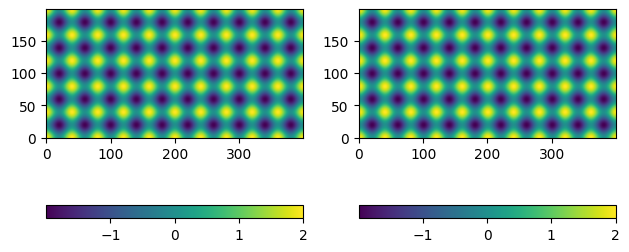

In [10]:
import matplotlib.pyplot as plt
import numpy as np
Z = fxy(X, lambda1, A1, Y, lambda2, A2)
# plot with imshow
fig, ax = plt.subplots (ncols = 2)
im1 = ax[0].imshow (Z, origin = 'lower')
fig.colorbar(im1, ax=ax [0], orientation = 'horizontal')

im2 = ax[1].imshow (Z, origin = 'lower', interpolation = 'bessel')
fig.colorbar(im2, ax=ax [1], orientation = 'horizontal')

plt.tight_layout ()

![](data/partie2-6.png)

### Partie 3 - Affichage de l'échelle en unités S.I.

7. Déclarer les 4 listes LISTEn, en argument de la méthode _set_xticks_ dans la cellule suivante, pour que l'échelle de l'image s'affiche en mètres, sur cinq graduations de 0 à $L_{x,y}$ inclus.

**Indication :** La méthode _set_xticks_ d'un graphique _ax_ permet d'imposer les valeurs numériques, appelées _ticks_,  affichées sur l'axe des abscisses.
Il est de surcroît possible de remplacer les valeurs numériques choisies par une liste arbitraire d'étiquettes appelées _labels_ pourvu que _ticks_ et _labels_ aient le même nombre d'éléments (voir annexes).

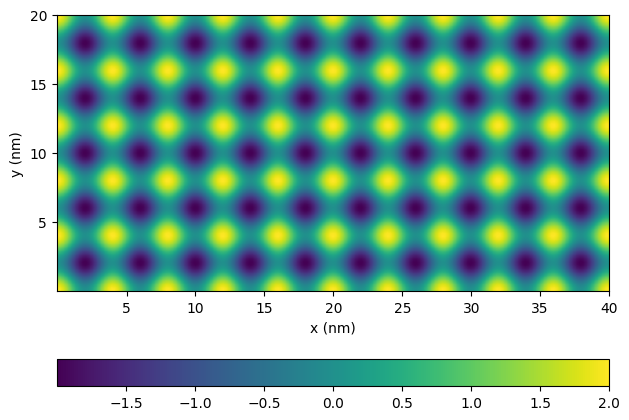

In [26]:
fig, ax = plt.subplots ()
im = ax.imshow (Z, origin = 'lower')
LISTE1 = [50, 100, 150, 200, 250, 300, 350, 400]
LISTE2 = [5, 10, 15, 20, 25, 30, 35, 40]
LISTE3 = [50, 100, 150, 200]
LISTE4 = [5, 10, 15, 20]

Nticks = 5
ax.set_xticks (LISTE1, LISTE2)
ax.set_yticks (LISTE3, LISTE4)
ax.set_aspect (1)
xlabel = 'x (nm)'
ylabel = 'y (nm)'
ax.set_xlabel (xlabel)
ax.set_ylabel (ylabel)
fig.colorbar(im, ax=ax, orientation = 'horizontal')
plt.tight_layout ()

![](data/partie3.png)

_Remarque :_ La commande _set_aspect(1)_ est sans effet car _imshow()_ ne prend en compte que des pixels carrés et non rectangulaire comme c'est le cas ici; en conséquence, le rapport d'aspect de $Z$ représenté comme une image est effectivement rectangulaire.

### Partie 4 - Représentation 2D avec la fonction matplotlib _pcolor_ et tracé de contours

9. La fonction _pcolor_ permet de représenter en échelle de couleurs le graphe des valeurs prises par une fonction à deux variables sans spposer l'existence de pixels carrés.
Vérifier à la lecture du graphe que la représentation est cohérente avec la définition de la fonction $f$.

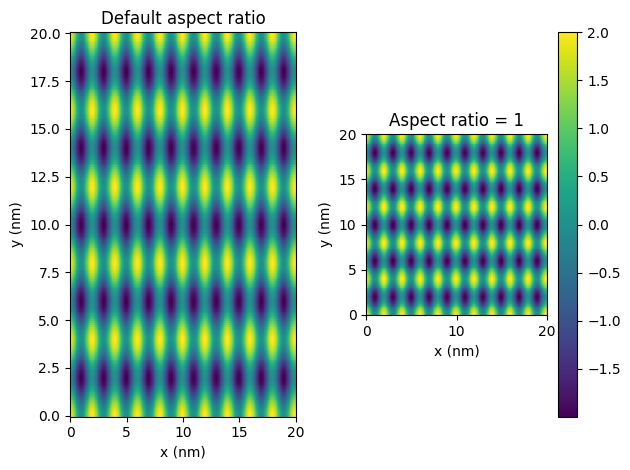

In [13]:
#plot with pcolor
fig, ax = plt.subplots (ncols = 2)
ax[0].pcolor (X, Y, Z)
ax[0].set_xlabel (xlabel)
ax[0].set_ylabel (ylabel)
ax[0].set_title ('Default aspect ratio')


graph = ax[1].pcolor (X, Y, Z)
ax[1].set_xlabel (xlabel)
ax[1].set_ylabel (ylabel)
ax[1].set_title ('Aspect ratio = 1')
ax[1].set_aspect (1)
fig.colorbar(graph, ax=ax [1])
plt.tight_layout () # évite que les figures se chevauchent

![](data/partie4.png)

10. On se propose ici de coder une version simplifiée de la fonction _contour_ de matplotlib.
Il s'agit de représenter l'ensemble des points ayant une valeur donnée, $z_1$, avec une tolérance $\tau$ (c'est-à-dire $z_1 - \tau \le Z_{i, j} \le z_1 + \tau$).
Compléter la cellule ci-dessous en remplaçant XXX par les instructions produisant la figure affichée.

0.0


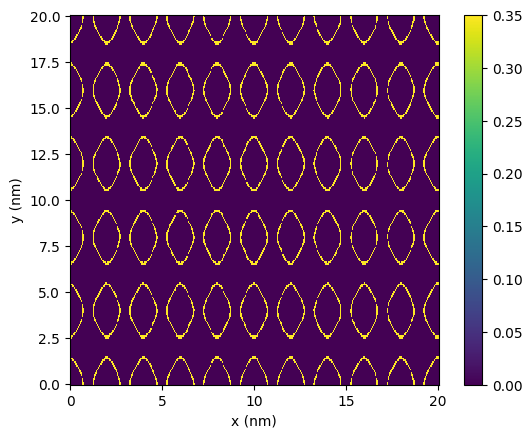

In [48]:
z1 = 1.65
levels = [2 + z1, 2 - z1]
#level = -np.sqrt(3)/2
tau = 1e-1
Zc = np.zeros ((ny, nx))
print(Zc[1][2])
for level in levels:
    for j in range (ny):
        for i in range (nx):
            if (level - tau <= Z[j][i] <= level + tau):
                Zc[j][i] = level
    

fig, ax = plt.subplots ()
graph = ax.pcolor (X, Y, Zc)
fig.colorbar(graph, ax=ax)
ax.set_aspect (1)
ax.set_xlabel (xlabel)
ax.set_ylabel (ylabel)
plt.show ()

![](data/partie5.png)

## Annexes

In [ ]:
help (ax.set_xticks)

Help on method set_xticks in module matplotlib.axes._base:

set_xticks(ticks, labels=None, *, minor=False, **kwargs) method of matplotlib.axes._axes.Axes instance
    Set the xaxis' tick locations and optionally tick labels.

    If necessary, the view limits of the Axis are expanded so that all
    given ticks are visible.

    Parameters
    ----------
    ticks : 1D array-like
        Array of tick locations (either floats or in axis units). The axis
        `.Locator` is replaced by a `~.ticker.FixedLocator`.

        Pass an empty list (``set_xticks([])``) to remove all ticks.

        Some tick formatters will not label arbitrary tick positions;
        e.g. log formatters only label decade ticks by default. In
        such a case you can set a formatter explicitly on the axis
        using `.Axis.set_major_formatter` or provide formatted
        *labels* yourself.

    labels : list of str, optional
        Tick labels for each location in *ticks*; must have the same length as
 

In [ ]:
help (np.polyfit)

Help on _ArrayFunctionDispatcher in module numpy:

polyfit(x, y, deg, rcond=None, full=False, w=None, cov=False)
    Least squares polynomial fit.

    .. note::
       This forms part of the old polynomial API. Since version 1.4, the
       new polynomial API defined in `numpy.polynomial` is preferred.
       A summary of the differences can be found in the
       :doc:`transition guide </reference/routines.polynomials>`.

    Fit a polynomial ``p(x) = p[0] * x**deg + ... + p[deg]`` of degree `deg`
    to points `(x, y)`. Returns a vector of coefficients `p` that minimises
    the squared error in the order `deg`, `deg-1`, ... `0`.

    The `Polynomial.fit <numpy.polynomial.polynomial.Polynomial.fit>` class
    method is recommended for new code as it is more stable numerically. See
    the documentation of the method for more information.

    Parameters
    ----------
    x : array_like, shape (M,)
        x-coordinates of the M sample points ``(x[i], y[i])``.
    y : array_like, sh

In [ ]:
help (np.polyval)

Help on _ArrayFunctionDispatcher in module numpy:

polyval(p, x)
    Evaluate a polynomial at specific values.

    .. note::
       This forms part of the old polynomial API. Since version 1.4, the
       new polynomial API defined in `numpy.polynomial` is preferred.
       A summary of the differences can be found in the
       :doc:`transition guide </reference/routines.polynomials>`.

    If `p` is of length N, this function returns the value:

        ``p[0]*x**(N-1) + p[1]*x**(N-2) + ... + p[N-2]*x + p[N-1]``

    If `x` is a sequence, then ``p(x)`` is returned for each element of ``x``.
    If `x` is another polynomial then the composite polynomial ``p(x(t))``
    is returned.

    Parameters
    ----------
    p : array_like or poly1d object
       1D array of polynomial coefficients (including coefficients equal
       to zero) from highest degree to the constant term, or an
       instance of poly1d.
    x : array_like or poly1d object
       A number, an array of numbers, or